# access lens and stablised runs analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [8]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [5]:
from functions import preproc_funcs as funcs

In [6]:
from functions import xr_lowess

In [7]:
import glob
import multiprocessing as mp

### transient

In [9]:
# Function to find the first file in each model's r1* directory
def find_all_lens_files(lens_pattern):
    all_paths = glob.glob(lens_pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[9][-12:-3]
        if model_identifier not in model_files:
            model_files[model_identifier] = path  # Store only the first file for each model
    return model_files


In [10]:
# tos_pattern_hist = '/g/data/lp01/CMIP6/CMIP/*/*/historical/r1i1*/Amon/tos/gr1.5/*/tos_Amon_*_historical_*_gr1.5_185001-201412.nc'
tos_pattern_hist = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/hist_*.nc'
tos_pattern_ssp5 = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/ssp_*.nc'

In [11]:
tos_files_hist = find_all_lens_files(tos_pattern_hist)
tos_files_ssp5 = find_all_lens_files(tos_pattern_ssp5)

In [12]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasetos
        tos_file_hist = tos_files_hist[model_identifier]
        tos_file_ssp = tos_files_ssp5[model_identifier]
        ds_sst_hist = xr.open_dataset(tos_file_hist)
        ds_sst_ssp = xr.open_dataset(tos_file_ssp)
        # add custom time ranges
        ds_sst_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_sst_ssp.time.dt.year[-1])
        ds_sst_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        #
        tos = xr.concat([ds_sst_hist, ds_sst_ssp], dim='time').tos.resample(time = 'AS-JUN').mean('time').load()  # SST data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        tos_anom = funcs.calc_anom_annual(tos, tos.sel(time = slice('1960', '1990')))
        tos_trend = funcs.calc_trend3d(tos_anom.sel(time = slice('1980', '2014')), 'time')
        tos_trend_pval = funcs.calc_trend_pval3d(tos_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        weights = np.cos(np.deg2rad(tos.lat))
        gmst_anom = tos_anom.weighted(weights).mean(('lat', 'lon'))
        nino34_index = funcs.detrend1d_check(tos_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        wp_sst = tos_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        ct_sst = tos_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        so_sst = tos_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, tos_trend, tos_trend_pval, gmst_anom, nino34_index, wp_sst, ct_sst, so_sst
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        return model_identifier



In [13]:
models_to_process = [(model) for model in tos_files_hist if model in tos_files_ssp5]

# Run multiprocessing and gather results
res_arr = []
with mp.Pool(processes=mp.cpu_count()) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [14]:
variants = np.array(res_arr)[:, 0]

In [15]:
variants

array(['r30i1p1f1', 'r20i1p1f1', '_r3i1p1f1', 'r10i1p1f1', '_r4i1p1f1',
       'r28i1p1f1', 'r27i1p1f1', 'r37i1p1f1', 'r38i1p1f1', 'r18i1p1f1',
       'r17i1p1f1', 'r40i1p1f1', 'r11i1p1f1', 'r31i1p1f1', '_r2i1p1f1',
       'r21i1p1f1', 'r16i1p1f1', 'r19i1p1f1', 'r26i1p1f1', '_r5i1p1f1',
       'r29i1p1f1', 'r39i1p1f1', 'r36i1p1f1', 'r25i1p1f1', '_r9i1p1f1',
       '_r6i1p1f1', 'r35i1p1f1', 'r15i1p1f1', 'r32i1p1f1', '_r1i1p1f1',
       'r22i1p1f1', 'r12i1p1f1', 'r14i1p1f1', '_r7i1p1f1', 'r24i1p1f1',
       '_r8i1p1f1', 'r34i1p1f1', 'r13i1p1f1', 'r33i1p1f1', 'r23i1p1f1'],
      dtype=object)

In [16]:
model_trend = xr.concat(np.array(res_arr)[:, 1], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'trend')
model_pval = xr.concat(np.array(res_arr)[:, 2], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'pval')


In [17]:
model_gmst_anom = xr.concat((np.array(res_arr)[:, 3]), dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
model_nino34_index = xr.concat((np.array(res_arr)[:, 4]), dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
model_wp_sst = xr.concat((np.array(res_arr)[:, 5]), dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
model_ep_sst = xr.concat((np.array(res_arr)[:, 6]), dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
model_so_sst = xr.concat((np.array(res_arr)[:, 7]), dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [18]:
out = xr.merge([model_trend, model_pval, model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])

In [19]:
def find_model_agreement1d(arr):
    agree = 0
    for val in arr:
        if val < 0.05:
            agree += 1
    return agree/len(arr)

def find_model_agreement3d(da, dim):
    return xr.apply_ufunc(find_model_agreement1d, da, input_core_dims=[[dim]], vectorize=True, dask='parallelized')

In [20]:
out['pval_agreement'] = find_model_agreement3d(out.pval, dim='model')

In [21]:
out.to_netcdf('./data/res/access_transient.nc')

### stable_runs

In [22]:
# Function to find the first file in each model's r1* directory
def find_all_stable_files(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[9][-8:-3]
        if model_identifier not in model_files:
            model_files[model_identifier] = path  # Store only the first file for each model
    return model_files


In [23]:
tos_pattern_stable = '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/*.nc'

In [24]:
tos_files_stable = find_all_stable_files(tos_pattern_stable)
tos_files_stable

{'B2050': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2050.nc',
 'B2045': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2045.nc',
 'B2035': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2035.nc',
 'B2040': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2040.nc',
 'B2030': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2030.nc',
 'B2055': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2055.nc',
 'B2060': '/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2060.nc'}

In [25]:
hist_access_r10 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/hist_r10i1p1f1.nc').tos.resample(time = 'AS-JUN').mean('time').load()
hist_access_r10

<xarray.DataArray 'tos' (time: 166, lat: 120, lon: 240)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7128506, -1.7124817, -1.7120235, ..., -1.7142824,
         -1.7137434, -1.7132931],
        [-1.7085022, -1.7082268, -1.7079923, ..., -1.7095268,
         -1.7091143, -1.7088464],
        [-1.7063258, -1.7060316, -1.7058275, ..., -1.7067484,
         -1.7067413, -1.7066791]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.631673 , -1.6315398, -1.6308559, ..., -1.6327343,
         -1.6322874, -1.6322078],
        [-1.6369117, -1.6371742, -1.6374321, ..., -1.6360364,
         -1.636414 , -1.636703 ],
        [-1.6336322, -1.6340133, -1.6342587, ..., -1.633132 ,
         -1.633118 , -1.633173 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.5572995, -1.5591258, -1.5613393, ..., -1.5511134,
         -1.5535018, -1.555246 ],
        [-1.5749787, -1.5757571, -1.5764196, ..., -1.5726528,
         -1.5734408, -1.5740592],
        [-1.5861565, -1.5868428, -1.5873173, ..., -1.5852233,
         -1.5852357, -1.5853654]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * time     (time) datetime64[ns] 1849-06-01 1850-06-01 ... 2014-06-01
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      Sea Surface Temperature
    units:          degC
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello
    history:        2020-06-05T04:59:57Z altered by CMOR: replaced missing va...

In [26]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasetos
        tos_file_stable = tos_files_stable[model_identifier]
        ds_sst_stable = xr.open_dataset(tos_file_stable).resample(time = 'AS-JUN').mean('time').load()
        # add custom time ranges
        stable_start_year = int(model_identifier[1:])
        stable_end_year = int(stable_start_year) + 1000
        ds_sst_stable['time'] = xr.cftime_range(f'{stable_start_year}-01-01', f'{stable_end_year + 1}-01-01', freq='1Y')
        tos = ds_sst_stable.sst
        #
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        tos_anom = funcs.calc_anom_annual(tos, hist_access_r10.sel(time = slice('1960', '1990')))
        # tos_trend = funcs.calc_trend3d(tos_anom.sel(time = slice('1980', '2014')), 'time')
        # tos_trend_pval = funcs.calc_trend_pval3d(tos_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        weights = np.cos(np.deg2rad(tos.lat))
        gmst_anom = tos_anom.weighted(weights).mean(('lat', 'lon'))
        nino34_index = funcs.detrend1d_check(tos_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        wp_sst = tos_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        ct_sst = tos_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        so_sst = tos_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, gmst_anom, nino34_index, wp_sst, ct_sst, so_sst
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        return model_identifier



In [27]:
models_to_process = [(model) for model in tos_files_stable]

# Run multiprocessing and gather results
res_arr = []
with mp.Pool(processes=mp.cpu_count()) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [28]:
variants = np.array(res_arr)[:, 0]
variants

array(['B2050', 'B2045', 'B2035', 'B2040', 'B2030', 'B2055', 'B2060'],
      dtype=object)

In [10]:
# model_gmst_anom = xr.concat(np.array(res_arr)[:, 1], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
# model_nino34_index = xr.concat(np.array(res_arr)[:, 2], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
# model_wp_sst = xr.concat(np.array(res_arr)[:, 3], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
# model_ep_sst = xr.concat(np.array(res_arr)[:, 4], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
# model_so_sst = xr.concat(np.array(res_arr)[:, 5], dim=variants).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [11]:
# out = xr.merge([model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])

In [12]:
# out.to_netcdf('./data/res/access_stable.nc')

In [44]:
# access_stab

<xarray.Dataset>
Dimensions:       (time: 1031, model: 7)
Coordinates:
  * time          (time) object 2030-12-31 00:00:00 ... 3060-12-31 00:00:00
  * model         (model) object 'B2050' 'B2045' 'B2035' ... 'B2055' 'B2060'
Data variables:
    nino34_index  (model, time) float64 nan nan nan nan ... 2.372 2.483 2.315
    wp_sst        (model, time) float64 nan nan nan ... 0.5474 0.9808 -0.1091
    ep_sst        (model, time) float64 nan nan nan nan ... 2.611 2.686 3.071
    so_sst        (model, time) float64 nan nan nan nan ... 3.444 3.861 2.603

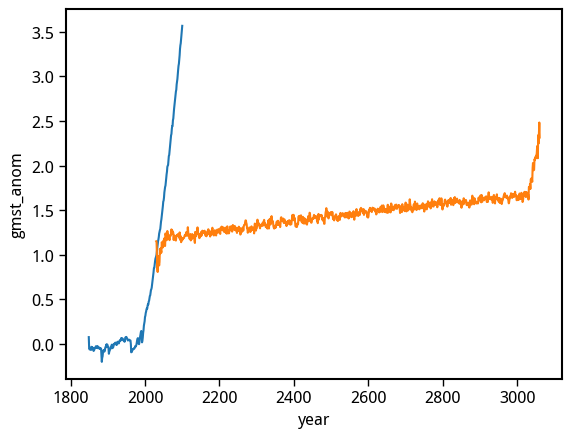

In [16]:
access_trans.groupby('time.year').mean('time').gmst_anom.mean('model').plot()
access_stab.groupby('time.year').mean('time').gmst_anom.mean('model').plot()

In [14]:
access_trans = xr.open_dataset('./data/res/access_transient.nc')
access_stab = xr.open_dataset('./data/res/access_stable.nc')

In [17]:
plt.style.use('dark_background')

In [37]:
access_trans_plot = access_trans.groupby('time.year').mean('time')

In [40]:
access_trans_roll = access_trans.rolling(time = 40).mean('time').groupby('time.year').mean('time')
access_stab_roll = access_stab.rolling(time = 40).mean('time').groupby('time.year').mean('time')

In [30]:
import seaborn as sns

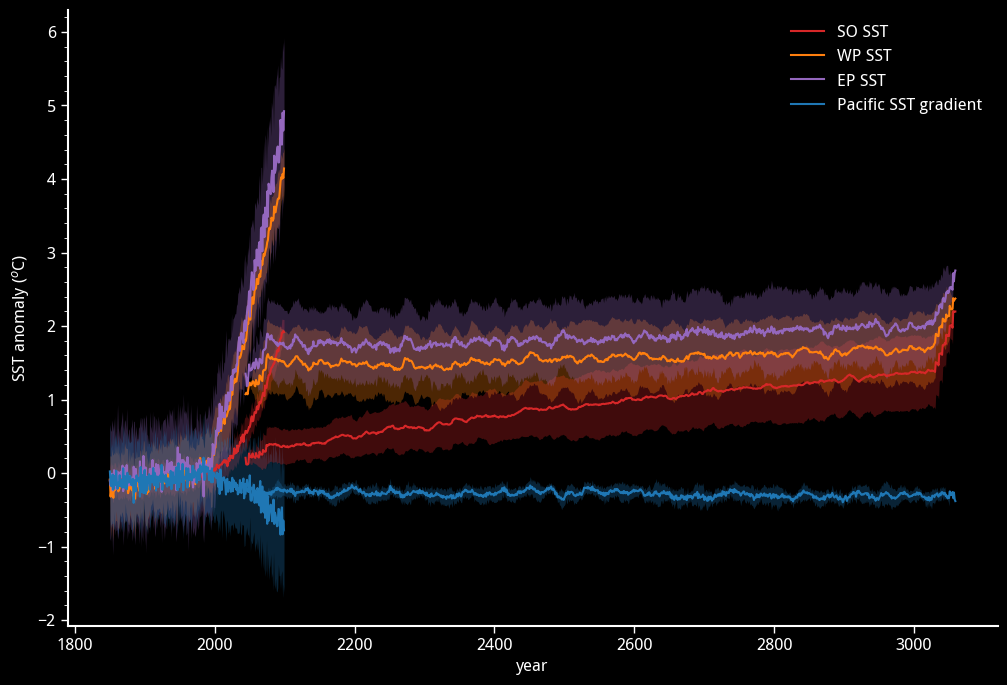

In [34]:
plt.figure(figsize=(12,8))
access_trans_plot.isel(year = slice(1, -1)).so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(access_trans_plot.isel(year = slice(1, -1)).year.to_numpy(), access_trans_plot.isel(year = slice(1, -1)).so_sst.mean('model') + access_trans_plot.isel(year = slice(1, -1)).so_sst.std('model'), access_trans_plot.isel(year = slice(1, -1)).so_sst.mean('model') - access_trans_plot.isel(year = slice(1, -1)).so_sst.std('model'), color='tab:red', alpha=0.3, lw=0.)
access_trans_plot.isel(year = slice(1, -1)).wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(access_trans_plot.isel(year = slice(1, -1)).year.to_numpy(), access_trans_plot.isel(year = slice(1, -1)).wp_sst.mean('model') + access_trans_plot.isel(year = slice(1, -1)).wp_sst.std('model'), access_trans_plot.isel(year = slice(1, -1)).wp_sst.mean('model') - access_trans_plot.isel(year = slice(1, -1)).wp_sst.std('model'), color='tab:orange', alpha=0.3, lw=0.)
access_trans_plot.isel(year = slice(1, -1)).ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(access_trans_plot.isel(year = slice(1, -1)).year.to_numpy(), access_trans_plot.isel(year = slice(1, -1)).ep_sst.mean('model') + access_trans_plot.isel(year = slice(1, -1)).ep_sst.std('model'), access_trans_plot.isel(year = slice(1, -1)).ep_sst.mean('model') - access_trans_plot.isel(year = slice(1, -1)).ep_sst.std('model'), color='tab:purple', alpha=0.3, lw=0.)

sst_grad = access_trans_plot.isel(year = slice(1, -1)).wp_sst - access_trans_plot.isel(year = slice(1, -1)).ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(access_trans_plot.isel(year = slice(1, -1)).year.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.3, lw=0.)


access_stab_roll.isel(year = slice(1, -1)).so_sst.mean('model').plot(color='tab:red')
plt.fill_between(access_stab_roll.isel(year = slice(1, -1)).year.to_numpy(), access_stab_roll.isel(year = slice(1, -1)).so_sst.mean('model') + access_stab_roll.isel(year = slice(1, -1)).so_sst.std('model'), access_stab_roll.isel(year = slice(1, -1)).so_sst.mean('model') - access_stab_roll.isel(year = slice(1, -1)).so_sst.std('model'), color='tab:red', alpha=0.3, lw=0.)
access_stab_roll.isel(year = slice(1, -1)).wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(access_stab_roll.isel(year = slice(1, -1)).year.to_numpy(), access_stab_roll.isel(year = slice(1, -1)).wp_sst.mean('model') + access_stab_roll.isel(year = slice(1, -1)).wp_sst.std('model'), access_stab_roll.isel(year = slice(1, -1)).wp_sst.mean('model') - access_stab_roll.isel(year = slice(1, -1)).wp_sst.std('model'), color='tab:orange', alpha=0.3, lw=0.)
access_stab_roll.isel(year = slice(1, -1)).ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(access_stab_roll.isel(year = slice(1, -1)).year.to_numpy(), access_stab_roll.isel(year = slice(1, -1)).ep_sst.mean('model') + access_stab_roll.isel(year = slice(1, -1)).ep_sst.std('model'), access_stab_roll.isel(year = slice(1, -1)).ep_sst.mean('model') - access_stab_roll.isel(year = slice(1, -1)).ep_sst.std('model'), color='tab:purple', alpha=0.3, lw=0.)

sst_grad = access_stab_roll.isel(year = slice(1, -1)).wp_sst - access_stab_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(access_stab_roll.isel(year = slice(1, -1)).year.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.3, lw=0.)
plt.legend(frameon=False, fontsize=12)
plt.ylabel('SST anomaly ($^{o}$C)')
# plt.xlabel('SST anomaly ($^{o}$C)')
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(which='minor', axis='x', bottom=False)
plt.savefig('./images/main.png', dpi=300, bbox_inches='tight')

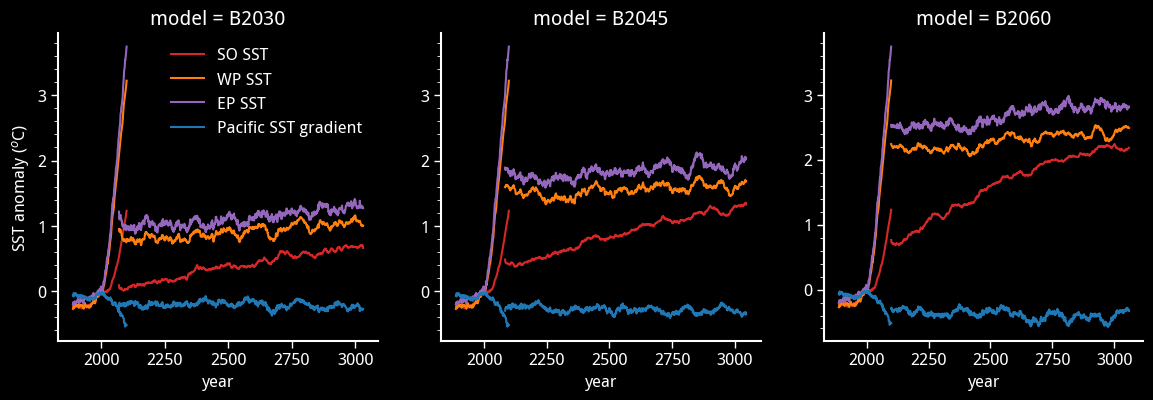

In [57]:
plt.figure(figsize=(14,4))
plt.subplot(131)
access_trans_roll.isel(year = slice(1, -1)).so_sst.sel(model='r10i1p1f1').plot(color='tab:red', label='SO SST')
access_trans_roll.isel(year = slice(1, -1)).wp_sst.sel(model='r10i1p1f1').plot(color='tab:orange', label='WP SST')
access_trans_roll.isel(year = slice(1, -1)).ep_sst.sel(model='r10i1p1f1').plot(color='tab:purple', label='EP SST')

sst_grad = access_trans_roll.isel(year = slice(1, -1)).wp_sst - access_trans_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='r10i1p1f1').plot(color='tab:blue', label='Pacific SST gradient')


access_stab_roll.isel(year = slice(1, -1)).so_sst.sel(model='B2030').plot(color='tab:red')
access_stab_roll.isel(year = slice(1, -1)).wp_sst.sel(model='B2030').plot(color='tab:orange')
access_stab_roll.isel(year = slice(1, -1)).ep_sst.sel(model='B2030').plot(color='tab:purple')

sst_grad = access_stab_roll.isel(year = slice(1, -1)).wp_sst - access_stab_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='B2030').plot(color='tab:blue')
plt.legend(frameon=False, fontsize=12)
plt.ylabel('SST anomaly ($^{o}$C)')
# plt.xlabel('SST anomaly ($^{o}$C)')
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(which='minor', axis='x', bottom=False)
# plt.savefig('./images/main.png', dpi=300, bbox_inches='tight')


plt.subplot(132)
access_trans_roll.isel(year = slice(1, -1)).so_sst.sel(model='r10i1p1f1').plot(color='tab:red', label='SO SST')
access_trans_roll.isel(year = slice(1, -1)).wp_sst.sel(model='r10i1p1f1').plot(color='tab:orange', label='WP SST')
access_trans_roll.isel(year = slice(1, -1)).ep_sst.sel(model='r10i1p1f1').plot(color='tab:purple', label='EP SST')

sst_grad = access_trans_roll.isel(year = slice(1, -1)).wp_sst - access_trans_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='r10i1p1f1').plot(color='tab:blue', label='Pacific SST gradient')


access_stab_roll.isel(year = slice(1, -1)).so_sst.sel(model='B2045').plot(color='tab:red')
access_stab_roll.isel(year = slice(1, -1)).wp_sst.sel(model='B2045').plot(color='tab:orange')
access_stab_roll.isel(year = slice(1, -1)).ep_sst.sel(model='B2045').plot(color='tab:purple')

sst_grad = access_stab_roll.isel(year = slice(1, -1)).wp_sst - access_stab_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='B2045').plot(color='tab:blue')
# plt.legend(frameon=False, fontsize=12)
# plt.ylabel('SST anomaly ($^{o}$C)')
# plt.xlabel('SST anomaly ($^{o}$C)')
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(which='minor', axis='x', bottom=False)
# plt.savefig('./images/main.png', dpi=300, bbox_inches='tight')


plt.subplot(133)
access_trans_roll.isel(year = slice(1, -1)).so_sst.sel(model='r10i1p1f1').plot(color='tab:red', label='SO SST')
access_trans_roll.isel(year = slice(1, -1)).wp_sst.sel(model='r10i1p1f1').plot(color='tab:orange', label='WP SST')
access_trans_roll.isel(year = slice(1, -1)).ep_sst.sel(model='r10i1p1f1').plot(color='tab:purple', label='EP SST')

sst_grad = access_trans_roll.isel(year = slice(1, -1)).wp_sst - access_trans_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='r10i1p1f1').plot(color='tab:blue', label='Pacific SST gradient')


access_stab_roll.isel(year = slice(1, -1)).so_sst.sel(model='B2060').plot(color='tab:red')
access_stab_roll.isel(year = slice(1, -1)).wp_sst.sel(model='B2060').plot(color='tab:orange')
access_stab_roll.isel(year = slice(1, -1)).ep_sst.sel(model='B2060').plot(color='tab:purple')

sst_grad = access_stab_roll.isel(year = slice(1, -1)).wp_sst - access_stab_roll.isel(year = slice(1, -1)).ep_sst
sst_grad.sel(model='B2060').plot(color='tab:blue')
# plt.legend(frameon=False, fontsize=12)
# plt.ylabel('SST anomaly ($^{o}$C)')
# plt.xlabel('SST anomaly ($^{o}$C)')
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(which='minor', axis='x', bottom=False)
plt.savefig('./images/different_gwls.png', dpi=300, bbox_inches='tight')